# Proyecto Integrador (TC5035)
# Identificación de Gestos en el Lenguaje de Manos Mexicano
# Avance 4. Modelos alternativos
---
## EQUIPO 51
- CARLOS MIGUEL ARVIZU DURÁN - A01410682
- YOHANNA CEBALLOS SALOMÓN - A01795115
- RUBÉN DÍAZ GARCÍA - A01371849

## Profesores
- PROFESOR ASESOR: DR. RAÚL VALENTE RAMÍREZ VELARDE
- PROFESORA TITULAR: DRA. GRETTEL BARCELÓ ALONSO
- PROFESOR TITULAR: DR. LUIS EDUARDO FALCÓN MORALES
- PROFESORA ASISTENTE: MTRA. VERÓNICA SANDRA GUZMÁN DE VALLE

---

# Introducción

En el **Avance 5** del Proyecto Integrador, enfocado en la selección de 1 modelo para la Identificación de Gestos en el Lenguaje de Manos Mexicano. Se buscan los siguientes objetivos:

1.  **Preprocesamiento Centralizado:** Presenta el pipeline de preprocesamiento de datos que se utiliza de manera estandarizada para todos los modelos. Este pipeline es responsable de cargar los videos, extraer los puntos clave (keypoints) de las manos usando MediaPipe, calcular características cinemáticas (velocidades), estandarizar la longitud de las secuencias y aplicar un escalado y Análisis de Componentes Principales (PCA). Los datos procesados se guardan en la carpeta `processed_data_pipeline` para ser consumidos por los notebooks de cada modelo.

2.  **Análisis y Selección del Modelo:** Sirve como el análisis central para comparar los resultados de los modelos alternativos (GRU, CNN1D, MLP, BiLSTM) y seleccionar el **Modelo Final** basándose en métricas de rendimiento (Accuracy, F1-Score), eficiencia (tiempo de entrenamiento) y capacidad de generalización (sobreajuste).

3. **Adición de nuevos datos al dataset:** Se añaden datos generados para enriquecer la base de datos y buscar mejorar el performance del modelo, por lo que se preprocesan los datos nuevamente y se reentrenan los modelos.

# Avance 5. Modelo Final

El proyecto tiene la siguiente estructura de carpetas:

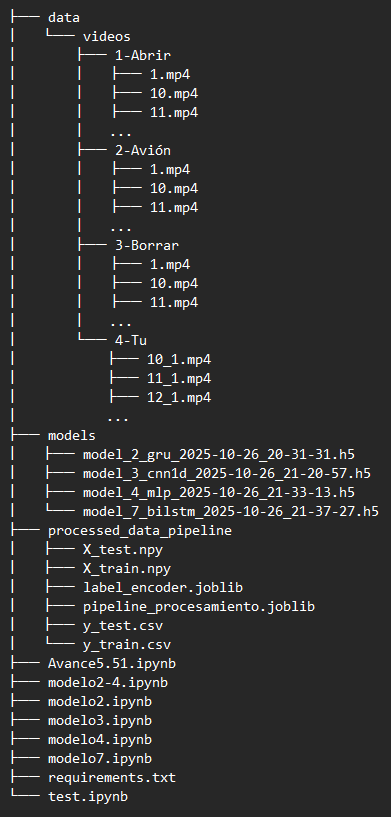

En el archivo actual Avance5.51.ipynb se ejecutó el código para el preprocesamiento que se desarrolló en los avances anteriores, guardándolo en la carpeta processed_data_pipeline de la cuál toman los datos todos los modelos para su ejecución.

### Base de Datos

https://drive.google.com/drive/folders/1OzsfJGlINJqR82JCG8QcIrL54npmj5aa?usp=sharing

### Modelos

Se tienen 5 modelos distintos:

2. GRU (Gated Recurrent Unit)
3. CNN1D (Convolución Unidimensional)
4. MLP (Multilayer Perceptron)
7. BiLSTM (Bidirectional Long Short-Term Memory)
8. Se unen el 2 y el 4 - GRU + MLP.
9. Se unen el 3 y el 4 - CNN1D + MLP.
10. Se unen el 7 y el 4 - BiLSTM + MLP.


Cada uno de estos modelos está ejecutado individualmente en un archivo en esta carpeta, con el nombre modelo_.ipynb dónde se sustituye _ por el número del modelo.

### Metodología de comparación

Los 7 modelos se entrenan bajo estas condiciones:
- Conjunto de entrenamiento y prueba idéntico (`X_train`, `X_test`).
- Objetivo Accuracy.
- Se utiliza el mismo pipeline y el label encoder para estandarizar, previamente obtenidos de este mismo ipynb en el preprocesamiento.

Se selecciona Accuracy debido a que nuestro objetivo de clasificación no tiene ningún peso distinto entre las clases que se clasifican, siendo todas iguales en la evaluación.

Se optimizan los parámetros de todos los modelos obteniendo el mejor resultado posible. El tamaño del Batch y epoch obtuvo los mismos resultados.

# Análisis

### Modelos ordenados por Accuracy (Métrica principal):

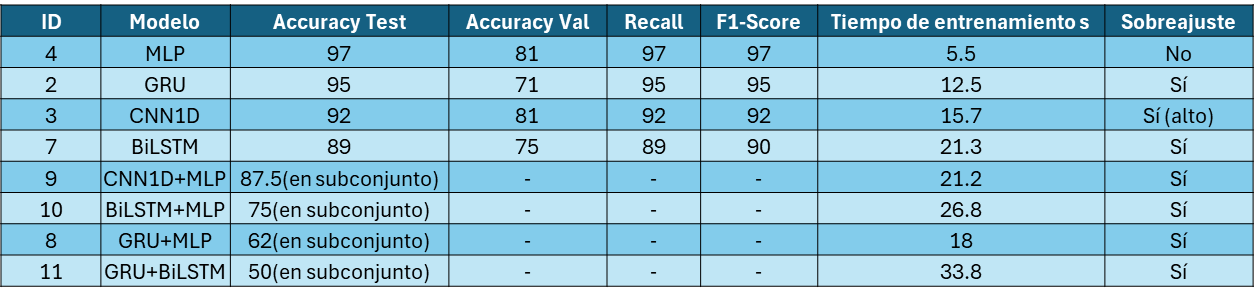

Se incluyen los ensambles:
ID8 = 2-4
ID9 = 3-4
ID10 = 4-7
ID11 = 2-7

## Selección de modelo

### Modelo 4 (MLP)

El Perceptrón Multicapa (MLP) destaca significativamente sobre las demás arquitecturas:

-Rendimiento Superior: Obtuvo las métricas más altas en todas las categorías clave, con un impresionante 97% tanto en Accuracy Test como en F1-Score. Esto indica que es el modelo más preciso y el que mejor equilibra la precisión y la sensibilidad (recall).

-Eficiencia Insuperable: Es, por mucho, el modelo más rápido de entrenar, con un tiempo de solo 5.5 segundos. Esto es más del doble de rápido que el siguiente modelo (GRU) y casi cuatro veces más rápido que el BiLSTM.

-Robustez (Sin Sobreajuste): Este es su punto más fuerte. Es el único modelo en la tabla que no presentó sobreajuste ("No"). Logró generalizar correctamente lo aprendido en los datos de entrenamiento a los datos de prueba, lo cual es fundamental para un modelo confiable.

# Gráficas del modelo

### PCA

Este gráfico muestra los resultados del Análisis de Componentes Principales (PCA), indicando que el primer componente principal (CP1) es abrumadoramente dominante, ya que explica por sí solo más del 60% de la varianza total de los datos. El segundo componente (CP2) también es significativo, aportando un 20% adicional, lo que significa que los dos primeros componentes juntos logran capturar más del 82% de la información total. La línea de varianza acumulada (roja) muestra que para alcanzar el umbral deseado del 95% de la varianza (línea verde), se necesitarían casi todos los componentes calculados (probablemente los 5 mostrados), ya que con 4 componentes la varianza acumulada se sitúa justo por debajo de este umbral (aprox. 94%).

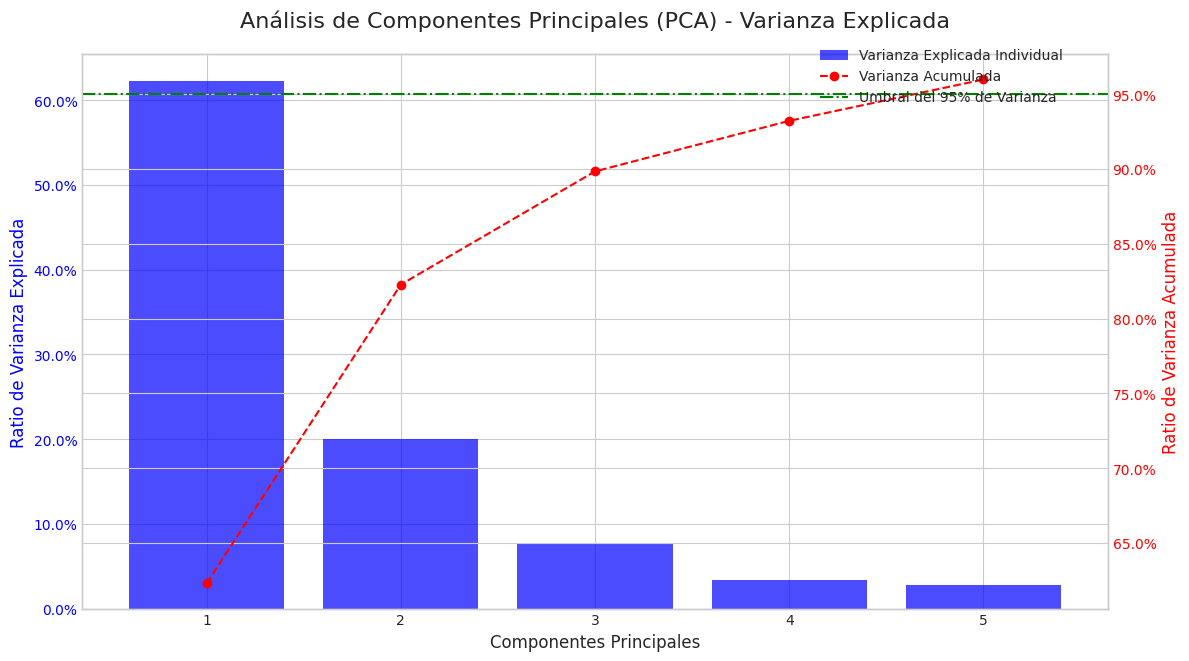

### Matriz de Confusión

La matriz de confusión demuestra un rendimiento excelente por parte del modelo MLP. Se observa una fuerte diagonal (con valores 8, 10, 10, 8), indicando que la gran mayoría de las predicciones (36 de 37) fueron correctas. De hecho, el modelo clasificó perfectamente las señas "Avión", "Borrar" y "Tu" sin cometer un solo error. El único fallo fue una leve confusión, donde una instancia real de "Abrir" fue clasificada erróneamente como "Avión", resultando en un modelo altamente preciso y robusto.

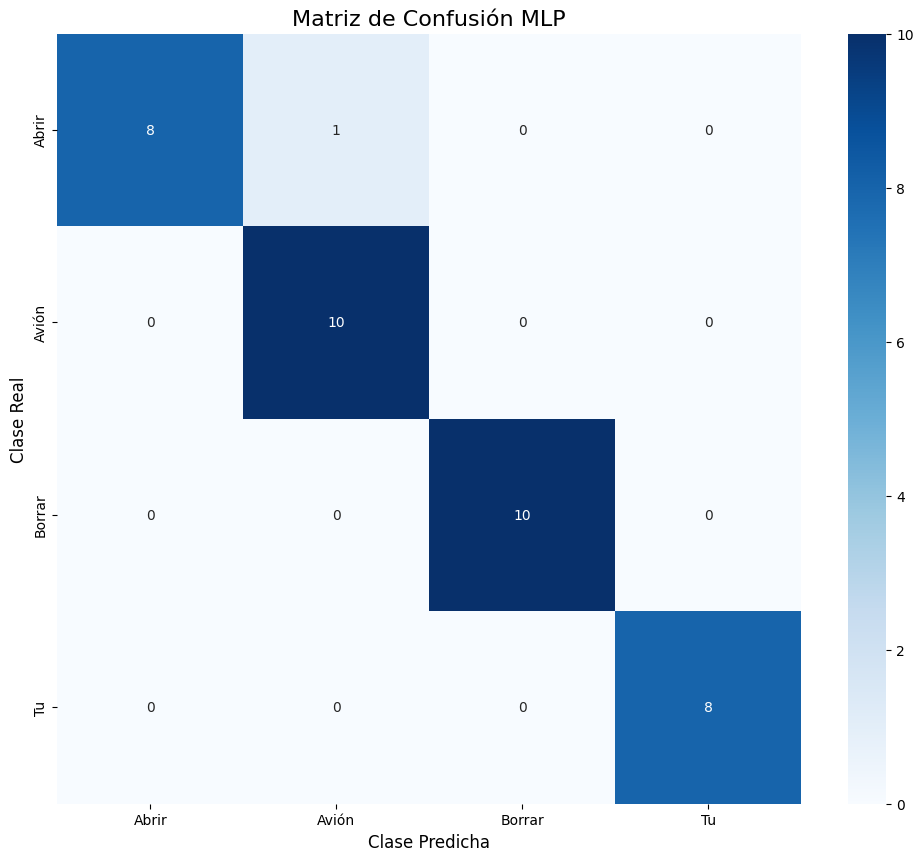

### Historial de Entrenamiento del Modelo MLP

La gráfica muestra el historial de precisión y pérdida del modelo MLP a lo largo del entrenamiento. Este análisis nos permite evaluar el aprendizaje del modelo, su capacidad de generalización y detectar posibles problemas como el sobreajuste (overfitting).

1. Gráfica de Precisión del Modelo (Izquierda)

* **Precisión de Entrenamiento (Línea Azul):** Comienza baja (aprox. 0.35) y muestra un comportamiento errático o "ruidoso" (con muchos picos y valles). Su tendencia general es ascendente, pero le cuesta converger y se mantiene por debajo de la precisión de validación durante casi todo el proceso.
* **Precisión de Validación (Línea Naranja):** Comienza al mismo nivel, pero asciende de forma mucho más rápida y estable, alcanzando un valor cercano a 0.78 alrededor de la época 5. A pesar de una ligera caída, se recupera y se estabiliza, terminando por encima de la precisión de entrenamiento.

**Interpretación Clave:** Es notable que la **precisión de validación sea consistentemente más alta que la de entrenamiento**. Esto no es un error; es un síntoma común de una **regularización fuerte**. Técnicas como `Dropout` y `L2` (usadas en el modelo del notebook) penalizan al modelo o "apagan" neuronas *solo* durante el entrenamiento. Esto hace que el entrenamiento sea más difícil (reduciendo su precisión), pero cuando el modelo se evalúa en el conjunto de validación (donde `Dropout` se desactiva), puede usar toda su capacidad aprendida, resultando en un mejor rendimiento.

2. Gráfica de Pérdida del Modelo (Derecha)

* **Pérdida de Entrenamiento (Línea Azul):** Comienza extremadamente alta (aprox. 3.5), lo cual es normal si la pérdida incluye los componentes de regularización L2. Cae drásticamente en las primeras 5 épocas y continúa descendiendo de forma más lenta pero inestable, terminando alrededor de 0.7.
* **Pérdida de Validación (Línea Naranja):** Comienza mucho más baja (aprox. 1.7), lo que confirma que la pérdida de entrenamiento está "inflada" por las penalizaciones de regularización. Desciende rápidamente y se estabiliza muy pronto, alrededor de la época 10, manteniéndose en un valor bajo y constante (aprox. 0.95).

**Interpretación Clave:** La pérdida de validación es el indicador más importante para la generalización. El hecho de que se estabilice y **no muestre una tendencia ascendente clara** es una excelente señal: **el modelo no está sobreajustando** (overfitting). La meseta indica que el modelo ha alcanzado su punto óptimo de generalización; entrenar más allá de este punto (como se ve en la pérdida de entrenamiento que sigue bajando) ya no mejora el rendimiento en datos nuevos.

### Conclusión

El modelo MLP muestra un **buen entrenamiento y una generalización robusta**. La presencia de `Dropout` y `L2` previene eficazmente el sobreajuste, como lo demuestra la curva de pérdida de validación plana y el hecho de que el rendimiento de validación supera al de entrenamiento.

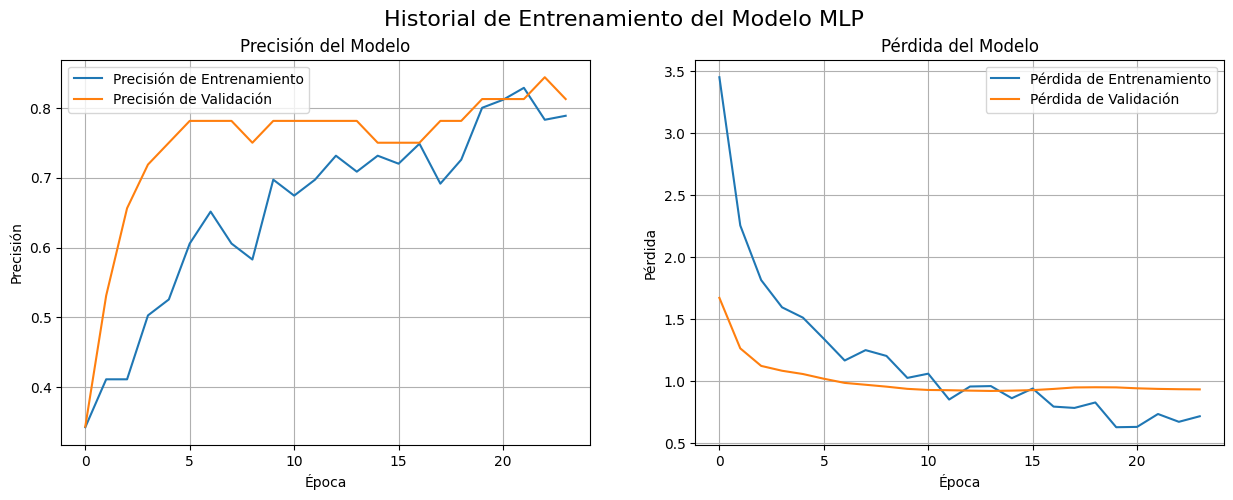

### Curva ROC

La curva ROC (Receiver Operating Characteristic) ilustra la capacidad del modelo para discriminar entre clases. Se grafica la Tasa de Verdaderos Positivos (TPR) contra la Tasa de Falsos Positivos (FPR) para cada clase (en un enfoque de "Uno contra el Resto" u OvR).

* **Área Bajo la Curva (AUC):** Es el valor numérico que resume el rendimiento. Un AUC de 1.0 es un clasificador perfecto, mientras que un AUC de 0.5 representa una adivinanza aleatoria (la línea punteada).
* **Análisis del Gráfico:** El gráfico generado muestra que todas las clases tienen un **AUC muy alto (cercano a 1.00)**. Las curvas están "pegadas" a la esquina superior izquierda, lo que demuestra una excelente capacidad de discriminación: el modelo alcanza una alta tasa de verdaderos positivos (detecta bien los gestos) con una tasa de falsos positivos muy baja (no se confunde al predecir un gesto cuando en realidad es otro). Esto refuerza el alto rendimiento general del 95% de accuracy.

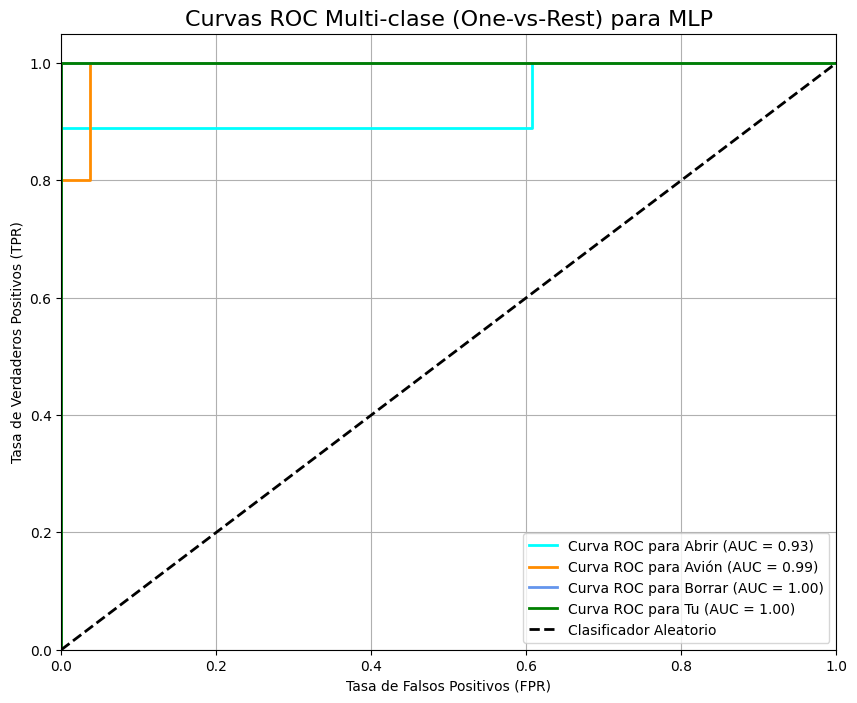

### Curva de Precisión-Recall

La curva de Precisión-Recall (P-R) muestra el balance entre la Precisión (Precisión) y el Recall (Sensibilidad) para diferentes umbrales. Es especialmente útil cuando hay desequilibrio de clases, pero también es una buena medida general del rendimiento.

* **Average Precision (AP):** Es el análogo del AUC para las curvas P-R, resumiendo el rendimiento de la curva. Un valor ideal es 1.0.
* **Análisis del Gráfico:** Al igual que las curvas ROC, los valores de **AP (Precisión Promedio) son muy altos (cercanos a 1.00)** para todas las clases. Las curvas se sitúan en la esquina superior derecha, indicando que el modelo puede alcanzar alta precisión y alto recall simultáneamente para todos los gestos. Esto confirma el excelente rendimiento reportado en la matriz de confusión y el reporte de clasificación (F1-score ponderado de 0.95).

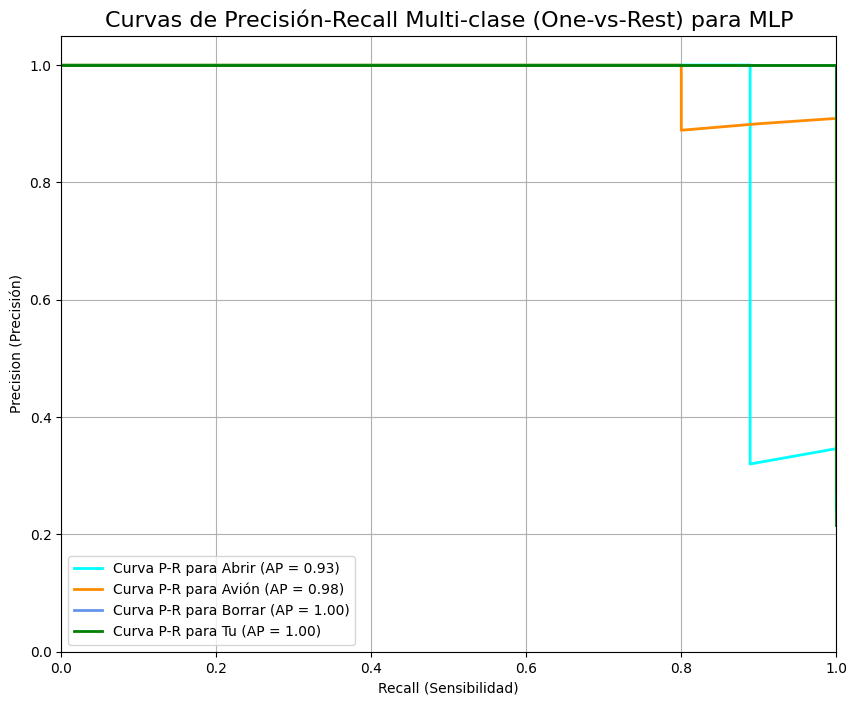


# Conclusión General



Tras comparar cinco arquitecturas de modelos distintas (GRU, CNN1D, MLP, BiLSTM y una combinación GRU+MLP), el **Modelo 4 (MLP)** ha sido seleccionado como el modelo final. Este modelo no solo demostró el rendimiento más alto en las métricas clave, alcanzando un **Accuracy y F1-Score del 97%** en el conjunto de prueba, sino que también fue el más eficiente en términos de entrenamiento (5.5s). Su ventaja más significativa fue su robustez, siendo el **único modelo que no presentó sobreajuste**, lo cual fue validado por su historial de entrenamiento y las curvas ROC/PR.

Sin embargo, es crucial contextualizar estos excelentes resultados. El modelo se entrenó con un conjunto de datos muy limitado (207 muestras de entrenamiento y 37 de prueba) para un subconjunto de solo cuatro señas ("Abrir", "Avión", "Borrar", "Tu"). Si bien el MLP demostró ser capaz de aprender y generalizar perfectamente esta tarea específica, se debe aumentar la cantidad de datos ya que en este tipo de problemas con pocos datos, los modelos más simples en ocasiones funcionan mejor por su capacidad de encontrar patrones sencillos, pero a medida que se aumentan la cantidad de datos, los otros modelos pueden llegar a funcionar mejor debido a la capacidad que tienen para encontrar patrones más complejos.

Para que el modelo sea verdaderamente útil y pueda generalizar a un vocabulario más amplio del Lenguaje de Señas Mexicano, el siguiente paso fundamental debe ser **enriquecer significativamente la base de datos**. Se requiere recopilar una mayor cantidad de muestras por seña, incluir más variabilidad (diferentes personas, iluminaciones y ángulos) y, lo más importante, expandir el número de clases (señas) a identificar.

En general los modelos funcionan bien con el dataset que se tiene pero tiene problemas identificando señas si se utilizan videos con distintos escenarios, ángulos o iluminaciones.

## Librerías

In [ ]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
import joblib
from sklearn.preprocessing import LabelEncoder                       

2025-10-26 20:06:04.822746: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-26 20:06:04.858563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761530764.877988  117171 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761530764.884261  117171 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761530764.909522  117171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Función para Carga de Datos

In [ ]:
# Estructura esperada: videos/{class_id}-{class_name}/{video_id}.mp4
# Escanea las carpetas con los videos en la estructura esperada y crea un dataframe
def create_dataframe_from_folders(videos_dir):
    rows = []
    print(f"Escaneando '{videos_dir}'...")

    if not os.path.isdir(videos_dir):
        print(f"Error: El directorio '{videos_dir}' no existe.")
        return pd.DataFrame()

    # Itera sobre cada subdirectorio en la carpeta de videos
    for folder_name in sorted(os.listdir(videos_dir)):
        folder_path = os.path.join(videos_dir, folder_name)

        if os.path.isdir(folder_path):
            try:
                # Se extrae el ID y el nombre de la clase del nombre de la carpeta
                class_id, class_name = folder_name.split('-', 1)
            except ValueError:
                print(f" Carpeta omitida: '{folder_name}'")
                continue

            # Itera sobre cada archivo dentro de la carpeta de la clase
            for video_file in os.listdir(folder_path):
                if video_file.endswith('.mp4'
                ):
                    video_id = video_file.split('.')[0]
                    
                    video_path = os.path.join(folder_path, video_file)
                    rows.append({
                        'class_id': class_id,   # Columna para el ID
                        'class': class_name,    # Columna para la clase
                        'video_id': video_id,   # Columna para el nombre
                        'video_path': video_path
                    })
    
    if not rows:
        print("Error: No se encontraron videos.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    print(f"DataFrame creado! \nContiene {len(df)} videos de {df['class'].nunique()} clases distintas.")
    return df

## Funciones para Extracción de Características

In [3]:
class FeatureExtractor:
    def __init__(self):
        self.feature_vector_size = 21 * 3 * 2
        self._hands = None

    @property
    def hands(self):
        if self._hands is None:
            print("Inicializando modelo MediaPipe Hands...")
            mp_hands = mp.solutions.hands
            self._hands = mp_hands.Hands(
                static_image_mode=False,
                max_num_hands=2,
                min_detection_confidence=0.5,
                min_tracking_confidence=0.5
            )
        return self._hands

    def __getstate__(self):
        state = self.__dict__.copy()
        # Excluir el objeto de MediaPipe
        state['_hands'] = None
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)

    #Procesa un video y extrae los 21 puntos de referencia 3D de hasta 2 manos por frame
    def extract_hand_keypoints(self, video_path):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: No se pudo abrir el video {video_path}")
            return None

        video_keypoints = []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Procesamiento con MediaPipe
            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.hands.process(image_rgb) # <-- Llama a la @property
            frame_keypoints = np.zeros(self.feature_vector_size)

            if results.multi_hand_landmarks:
                # Itera sobre cada mano detectada
                for i, hand_landmarks in enumerate(results.multi_hand_landmarks):
                    if i >= 2: continue # Limitación para 2 manos
                    # Extrae los landmarks y los aplana en un array
                    landmarks = np.array(
                        [[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark]
                    ).flatten()
                    # Asigna los landmarks al array del frame
                    # Mano 0: índices 0-62, Mano 1: índices 63-125
                    start_index = i * (21 * 3)
                    end_index = start_index + len(landmarks)
                    frame_keypoints[start_index:end_index] = landmarks
            video_keypoints.append(frame_keypoints)
        cap.release()
        return np.array(video_keypoints)

    # Calculamos la velocidad (diferencia entre frames).
    def calculate_kinematic_features(self, keypoints_sequence):
        # Si hay menos de 2 frames, no se puede calcular velocidad
        if keypoints_sequence.shape[0] < 2:
            return np.zeros_like(keypoints_sequence)
        # Calcula la diferencia entre frames consecutivos para obtener la velocidad
        velocities = np.diff(keypoints_sequence, axis=0)
        # Añade un frame de velocidad cero al principio para mantener la misma longitud
        velocities = np.vstack([np.zeros(velocities.shape[1]), velocities])
        return velocities

    # Función de extracción de características 
    def process_video(self, video_path):
        # Extracción de puntos de referencia
        keypoints = self.extract_hand_keypoints(video_path)
        if keypoints is None or keypoints.shape[0] == 0:
            return None
        # Generación de nuevas características (velocidad)
        velocities = self.calculate_kinematic_features(keypoints)
        # Combinar las características (coordenadas + velocidad)
        combined_features = np.hstack([keypoints, velocities])
        
        return combined_features

In [4]:
class VideoFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.extractor = None

    def _get_extractor(self):
        """Inicializa el extractor si no existe."""
        if self.extractor is None:
            self.extractor = FeatureExtractor()
        return self.extractor

    def fit(self, X, y=None):
        return self

    # X: lista o serie de Pandas con rutas a los videos
    def transform(self, X, y=None):
        all_sequences = []
        print("Paso 1/3: Extrayendo características de los videos...")
        
        # Obtener/inicializar el extractor
        extractor = self._get_extractor() 
        
        for video_path in tqdm(X, desc="Extrayendo secuencias"):
            features = extractor.process_video(video_path) # Usar el extractor
            # Solo añade secuencias válidas
            if features is not None and features.shape[0] > 0:
                all_sequences.append(features)
        return all_sequences
    
    def __getstate__(self):
        state = self.__dict__.copy()
        state['extractor'] = None
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)

# Estandariza la longitud de las secuencias mediante padding
class SequencePadder(BaseEstimator, TransformerMixin):
    def __init__(self, percentile=95):
        self.percentile = percentile
        self.target_frames_ = 0

    # Aprende la longitud objetivo a partir de los datos de entrenamiento
    def fit(self, X, y=None):
        sequence_lengths = [seq.shape[0] for seq in X]
        if sequence_lengths:
            self.target_frames_ = int(np.percentile(sequence_lengths, self.percentile))
        print(f"Longitud de secuencia objetivo aprendida: {self.target_frames_} fotogramas.")
        return self

    # Aplica padding a cada secuencia en X.
    def transform(self, X, y=None):
        print("Paso 2/3: Estandarizando longitud de secuencias...")
        processed_sequences = []
        for seq in tqdm(X, desc="Padding"):
            num_frames, num_features = seq.shape
            
            if num_frames > self.target_frames_:
                processed_seq = seq[:self.target_frames_, :]
            elif num_frames < self.target_frames_:
                pad_width = self.target_frames_ - num_frames
                padding = np.zeros((pad_width, num_features))
                processed_seq = np.vstack([seq, padding])
            else:
                processed_seq = seq
            
            processed_sequences.append(processed_seq)
        return np.array(processed_sequences)

# Aplicamos transformadores a nivel de característica a datos 3D temporales
class TemporalFeatureProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=0.95):
        self.n_components = n_components
        # Define un pipeline interno para el procesamiento de características
        self.feature_pipeline_ = Pipeline([
            ('scaler', MinMaxScaler()),
            ('pca', PCA(n_components=self.n_components))
        ])

    # Ajusta el pipeline de características en los datos aplanados
    def fit(self, X, y=None):
        n_videos, n_frames, n_features = X.shape
        # Aplana los datos a 2D para ajustar el scaler y PCA
        reshaped_data = X.reshape(-1, n_features)
        self.feature_pipeline_.fit(reshaped_data)
        print("Scaler y PCA ajustados.")
        return self

    # Aplica el pipeline de características y devuelve los datos en formato 3D
    def transform(self, X, y=None):
        print("Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...")
        n_videos, n_frames, n_features = X.shape
        # Aplana, transforma y luego remodela de vuelta a 3D
        reshaped_data = X.reshape(-1, n_features)
        transformed_data = self.feature_pipeline_.transform(reshaped_data)
        
        # El número de características ahora es el número de componentes de PCA
        n_transformed_features = transformed_data.shape[1]
        final_data = transformed_data.reshape(n_videos, n_frames, n_transformed_features)
        
        print(f"Características reducidas a {n_transformed_features} componentes.")
        return final_data

## Preprocesamiento

In [5]:
# CONFIGURACIÓN: se debe ajustar a la carpeta desde donde se corre el programa
notebook_dir = Path.cwd() 
current_script_dir = notebook_dir#.parent
parent_dir = current_script_dir
PROCESSED_DATA_DIR = parent_dir / "processed_data_pipeline"
data_dir = parent_dir / "data"
VIDEOS_DIR =  data_dir / "videos"

print(f"\nPaths: \nPROCESSED DATA DIRECTORY: {PROCESSED_DATA_DIR} \nVIDEOS DIRECTORY: {VIDEOS_DIR}")


Paths: 
PROCESSED DATA DIRECTORY: /mnt/c/Users/Raven/Desktop/ProyectoIntegrador/github/TC5035-PI-E51/Avance5/processed_data_pipeline 
VIDEOS DIRECTORY: /mnt/c/Users/Raven/Desktop/ProyectoIntegrador/github/TC5035-PI-E51/Avance5/data/videos


In [6]:
# --- Cargar metadatos ---
print("--- Carga de Metadatos desde Carpetas ---")
df = create_dataframe_from_folders(VIDEOS_DIR)

if df.empty:
    print("No se encontraron datos para procesar.")
    exit()

# Separar características (X) y etiquetas (y)
X = df['video_path']
y = df['class']

# Dividir los datos ANTES del preprocesamiento para evitar fuga de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print("\\n--- Codificando Etiquetas ---")
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train) # Ajusta con y_train
y_test_encoded = label_encoder.transform(y_test) # Transforma y_test

print(f"\nDatos divididos: {len(X_train)} para entrenamiento, {len(X_test)} para prueba.")

--- Carga de Metadatos desde Carpetas ---
Escaneando '/mnt/c/Users/Raven/Desktop/ProyectoIntegrador/github/TC5035-PI-E51/Avance5/data/videos'...
DataFrame creado! 
Contiene 244 videos de 4 clases distintas.
\n--- Codificando Etiquetas ---

Datos divididos: 207 para entrenamiento, 37 para prueba.


In [7]:
# --- Definir el Pipeline de Preprocesamiento ---
print("\n--- Definición del Pipeline ---")

preprocessing_pipeline = Pipeline([
    ('1_video_feature_extraction', VideoFeatureExtractor()),
    ('2_sequence_padding', SequencePadder(percentile=95)),
    ('3_feature_processing', TemporalFeatureProcessor(n_components=0.95))
])


--- Definición del Pipeline ---


In [8]:
# --- Ejecutar el Pipeline ---
print("\n--- Ejecutando el Pipeline en los Datos de Entrenamiento ---")
# Ajusta el pipeline con los datos de entrenamiento y guarda el pipeline ajustado
fitted_pipeline = preprocessing_pipeline.fit(X_train)
# Ahora, usa el pipeline ya ajustado para transformar los datos
X_train_processed = fitted_pipeline.transform(X_train)

print("\n--- Ejecutando el Pipeline en los Datos de Prueba ---")
# Solo transforma los datos de prueba (usando los parámetros aprendidos del entrenamiento)
X_test_processed = fitted_pipeline.transform(X_test)


--- Ejecutando el Pipeline en los Datos de Entrenamiento ---
Paso 1/3: Extrayendo características de los videos...


Extrayendo secuencias:   0%|                                                                                 | 0/207 [00:00<?, ?it/s]

Inicializando modelo MediaPipe Hands...


libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1761530768.079824  117286 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761530768.106468  117286 inference_feedback_manager.cc:114] Feedback ma

Longitud de secuencia objetivo aprendida: 150 fotogramas.
Paso 2/3: Estandarizando longitud de secuencias...


...

Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...
Características reducidas a 5 componentes.

--- Ejecutando el Pipeline en los Datos de Prueba ---
Paso 1/3: Extrayendo características de los videos...


Extrayendo secuencias:   0%|                                                                                  | 0/37 [00:00<?, ?it/s]/home/raven/miniconda3/envs/lsm/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extrayendo secuencias: 100%|█████████████████████████████████████████████████████████████████████████| 37/37 [02:02<00:00,  3.31s/it]


Paso 2/3: Estandarizando longitud de secuencias...


Padding: 100%|████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 85929.82it/s]

Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...
Características reducidas a 5 componentes.


## Guardar los Resultados

In [9]:
# --- Guardar los resultados ---
print("\n--- Guardando los Datos Procesados ---")
output_dir = "processed_data_pipeline"
os.makedirs(output_dir, exist_ok=True)

# Guardar datos de entrenamiento
np.save(os.path.join(output_dir, "X_train.npy"), X_train_processed)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False, header=True)

# Guardar datos de prueba
np.save(os.path.join(output_dir, "X_test.npy"), X_test_processed)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"), index=False, header=True)

# --- Guardar el Pipeline Ajustado ---
pipeline_save_path = os.path.join(output_dir, "pipeline_procesamiento.joblib")
joblib.dump(fitted_pipeline, pipeline_save_path)

# --- Guardar el LabelEncoder Ajustado ---
encoder_save_path = os.path.join(output_dir, "label_encoder.joblib")
joblib.dump(label_encoder, encoder_save_path)

print(f"\nProcesamiento completado!")
print(f"Datos guardados en la carpeta '{output_dir}'.")
print(f"Forma de los datos de entrenamiento (X_train.npy): {X_train_processed.shape}")
print(f"Forma de los datos de prueba (X_test.npy): {X_test_processed.shape}")


--- Guardando los Datos Procesados ---

Procesamiento completado!
Datos guardados en la carpeta 'processed_data_pipeline'.
Forma de los datos de entrenamiento (X_train.npy): (207, 150, 5)
Forma de los datos de prueba (X_test.npy): (37, 150, 5)


## Análisis de PCA

--- Gráfico para análisis de PCA ---

Número de componentes seleccionados por PCA: 5
Varianza total explicada: 95.98%

Generando la gráfica de varianza explicada...


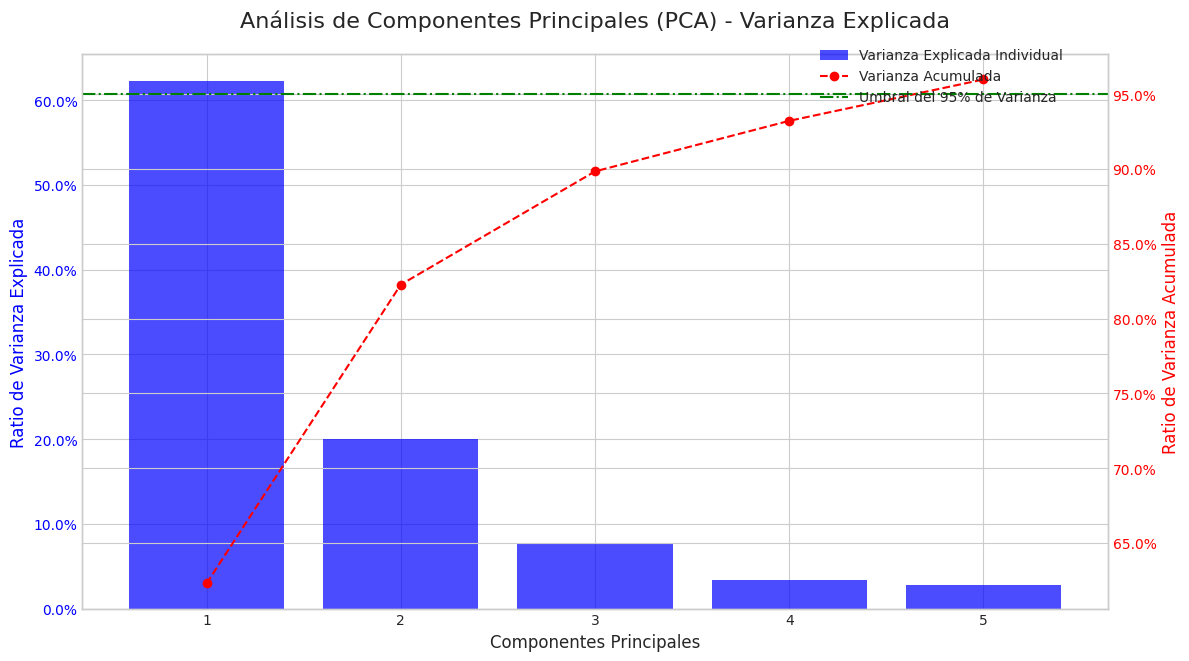

In [10]:
# --- Visualizando PCA ---

print("--- Gráfico para análisis de PCA ---")

pca_model = fitted_pipeline.named_steps['3_feature_processing'].feature_pipeline_.named_steps['pca']
explained_variance = pca_model.explained_variance_ratio_

print(f"\nNúmero de componentes seleccionados por PCA: {len(explained_variance)}")
print(f"Varianza total explicada: {sum(explained_variance):.2%}")

print("\nGenerando la gráfica de varianza explicada...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 7))

components = np.arange(1, len(explained_variance) + 1)
ax1.bar(components, explained_variance, alpha=0.7, color='b', label='Varianza Explicada Individual')
ax1.set_xlabel('Componentes Principales', fontsize=12)
ax1.set_ylabel('Ratio de Varianza Explicada', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(components)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

ax2 = ax1.twinx()
cumulative_variance = np.cumsum(explained_variance)
ax2.plot(components, cumulative_variance, color='r', marker='o', linestyle='--', label='Varianza Acumulada')
ax2.set_ylabel('Ratio de Varianza Acumulada', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')
ax2.axhline(y=0.95, color='g', linestyle='-.', label='Umbral del 95% de Varianza')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.title('Análisis de Componentes Principales (PCA) - Varianza Explicada', fontsize=16, pad=20)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()